In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os
import sys

parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
# MPC import
import numpy as np
from LinearMPC_tracking.MPCVelControl import MPCVelControl
from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis, plot_static_states_inputs

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [3]:
Ts = 0.05
sim_time = 10.0
H = 2.0

# initial state: origin
x0 = np.zeros(12)

# reference: 3 m/s for x, y, z and 35 deg for roll
ref = np.zeros(12)
ref[5] = 35 * np.pi / 180 # gamma
ref[6] = 3.0 # vx
ref[7] = 3.0 # vy
ref[8] = 3.0 # vz

rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc = MPCVelControl().new_controller(rocket, Ts, H, x_target=ref, use_terminal_set=True)

t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, _ = rocket.simulate_control(
    mpc, sim_time, H, x0, x_target=ref, method="linear"
)

ref_traj = ref.reshape(-1, 1).repeat(t_cl.shape[0]-1, axis=1)

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:, :-1], u_cl, T_ol=t_ol[..., :-1], X_ol=x_ol, U_ol=u_ol, Ref=ref_traj);


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Terminal set added with 16 inequalities.
Terminal set added with 16 inequalities.
Terminal set added with 2 inequalities.
Terminal set added with 42 inequalities.
Simulating time 0.00: 
Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 

/home/ilyas/miniconda3/envs/mpc2025/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



Simulating time 0.20: 
 State alpha violation: -0.17 < -0.17, 
 State beta violation: 0.17 > 0.17, 
Simulating time 0.25: 
 State alpha violation: -0.17 < -0.17, 
 State beta violation: 0.17 > 0.17, 
Simulating time 0.30: 
Simulating time 0.35: 
 State alpha violation: -0.17 < -0.17, 
 State beta violation: 0.17 > 0.17, 
Simulating time 0.40: 
Simulating time 0.45: 
 State alpha violation: -0.17 < -0.17, 
 State beta violation: 0.17 > 0.17, 
Simulating time 0.50: 
Simulating time 0.55: 
 State alpha violation: -0.17 < -0.17, 
 State beta violation: 0.17 > 0.17, 
Simulating time 0.60: 
Simulating time 0.65: 
 State alpha violation: -0.17 < -0.17, 
 State beta violation: 0.17 > 0.17, 
Simulating time 0.70: 
Simulating time 0.75: 
Simulating time 0.80: 
Simulating time 0.85: 
Simulating time 0.90: 
Simulating time 0.95: 
Simulating time 1.00: 
Simulating time 1.05: 
Simulating time 1.10: 
Simulating time 1.15: 
Simulating time 1.20: 
Simulating time 1.25: 
 State alpha violation: -0.17 <

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

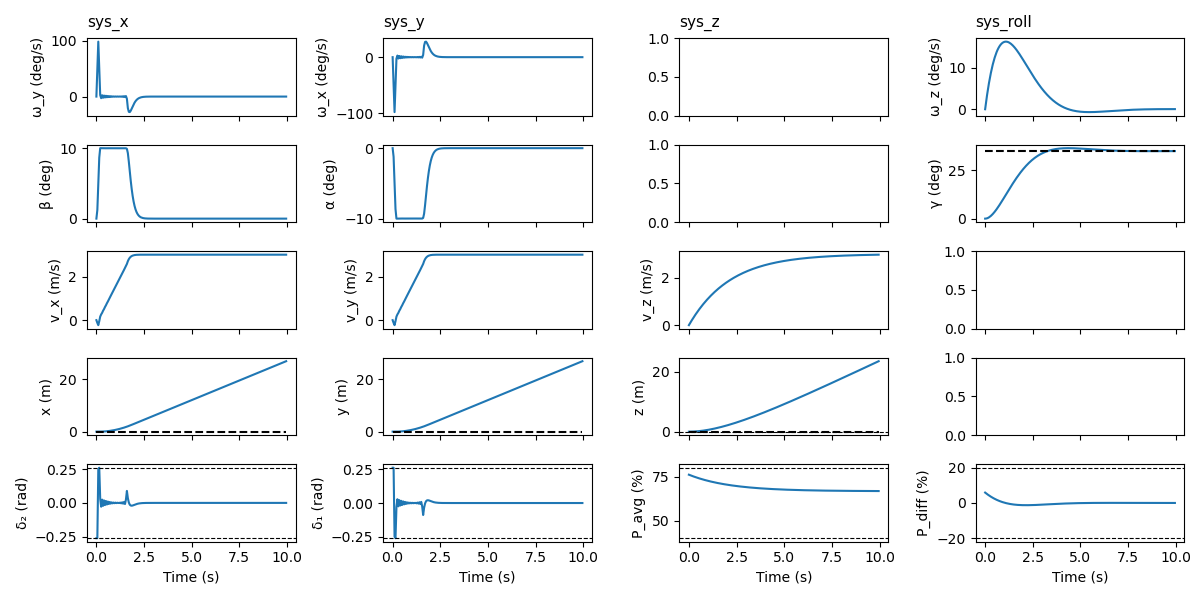

In [ ]:
import matplotlib.pyplot as plt

# hack to intercept the figure
old_show = plt.show
def new_show():
    plt.savefig('del3_2_sim.png')
    old_show()

plt.show = new_show
plot_static_states_inputs(t_cl[:-1], x_cl[:, :-1], u_cl, Ref=ref_traj)
plt.show = old_show